In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import warnings
warnings.filterwarnings('ignore')
print("库加载成功")

库加载成功


导入库
1.导入 NumPy，用于数值计算。
2.导入 Pandas，用于数据读取和处理。
3.导入 Matplotlib，用于绘图。
4.导入 Seaborn，美化统计图表。
5.核心导入：导入支持向量机分类器 SVC。SVC 支持多种核函数（linear, rbf, poly, sigmoid）。
6.关键导入：导入标准化工具。SVM 对特征尺度极其敏感，必须将所有特征缩放到相同的范围（均值0，方差1）。
7.导入数据划分和网格搜索工具。
8.导入评估指标。
9.忽略警告，保持输出整洁。

In [16]:
train_df=pd.read_csv('train.csv')
print(f"训练集形状：{train_df.shape}")
test_df=pd.read_csv('test.csv')
print(f"测试集形状：{test_df.shape}")

训练集形状：(42000, 785)
测试集形状：(28000, 784)


加载数据
1.读取训练数据。MNIST 训练集有 42000 行，第一列是标签（0-9），后面 784 列是 28×28 像素值（0~255）。
2.输出 (42000, 785)。
3.读取测试数据。测试集有 28000 行，没有标签列，只有 784 个像素列。

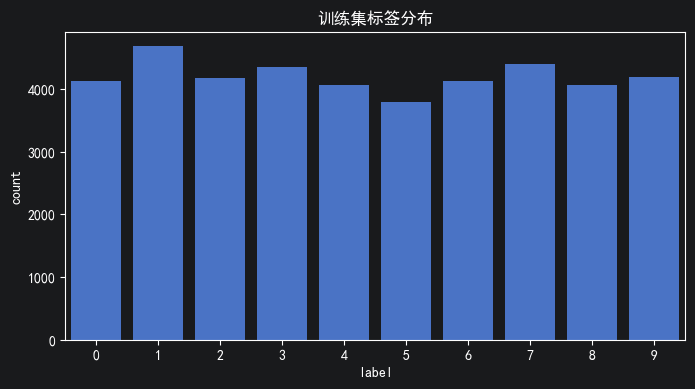

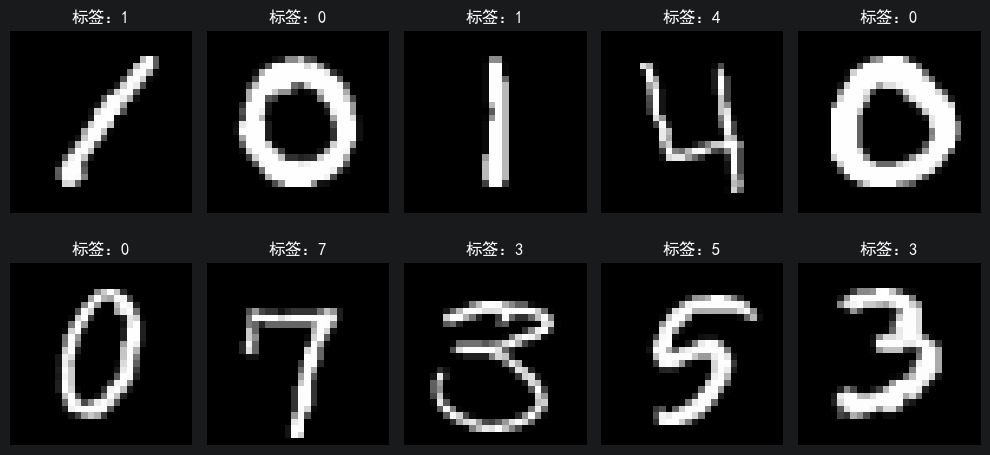

In [17]:
train_df.head()
plt.rcParams['font.sans-serif']=['SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False
plt.figure(figsize=(8,4))
sns.countplot(x=train_df['label'])
plt.title("训练集标签分布")
plt.show()
fig,axes=plt.subplots(2,5,figsize=(10,5))
axes=axes.ravel()
for i in range(10):
    image_data=train_df.iloc[i,1:].values.reshape(28,28)
    axes[i].imshow(image_data,cmap='gray')
    axes[i].set_title(f'标签：{train_df.iloc[i,0]}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

数据预览与可视化
1.查看前5行数据格式：第一列 label（0~9），后 784 列为像素值。
2.绘制标签分布柱状图，检查各类别是否平衡。MNIST 各类别大致均衡（每个数字约 4000 个样本）。
3.取第 i 行的第 1 列到最后一列（跳过 label），转为 28×28 的二维数组，用于显示为图片。
4.以灰度图显示数字图像。

In [18]:
X=train_df.drop('label',axis=1).values
y=train_df['label'].values
X_test_submit=test_df.values
print(f"训练特征形状：{X.shape}")
print(f"训练标签形状：{y.shape}")
print(f"测试特征形状：{X_test_submit.shape}")

训练特征形状：(42000, 784)
训练标签形状：(42000,)
测试特征形状：(28000, 784)


数据预处理——分离特征和标签
1.移除标签列，得到 42000×784 的特征矩阵，转换为 NumPy 数组。
2.提取标签列（0~9），长度为 42000 的一维数组。
3.测试集没有标签列，直接转为 NumPy 数组，形状为 (28000, 784)。

In [19]:
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"训练集：{X_train.shape}")
print(f"验证集：{X_val.shape}")

训练集：(33600, 784)
验证集：(8400, 784)


划分训练集和验证集
1.80% 训练（33600 张），20% 验证（8400 张）。
2.分层抽样，确保训练集和验证集中每个数字的比例与原始数据一致。
3.固定随机种子，可复现。

In [20]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_val_scaled=scaler.transform(X_val)
X_test_scaled=scaler.transform(X_test_submit)
print(f"标准化后训练集均值：{X_train_scaled.mean():.3f}")
print(f"标准化后训练集标准差：{X_train_scaled.std():.3f}")

标准化后训练集均值：0.000
标准化后训练集标准差：0.949


特征缩放（SVM 关键步骤！）
1.创建标准化器。StandardScaler 将每个特征减去均值再除以标准差，使数据服从 均值为0，标准差为1 的标准正态分布。
2.先在训练集上拟合（计算每个像素列的均值和标准差），然后转换训练数据。
3.使用训练集计算出的均值和标准差转换验证集。绝对不能在验证集上重新拟合！
4.同理，用训练集的统计量转换测试提交数据。

In [21]:
X_train_small=X_train_scaled[:10000]
y_train_small=y_train[:10000]
print("正在训练SVM（RBF核）...")
svm_base=SVC(kernel='rbf',C=1.0,gamma='scale',random_state=42,verbose=True)
svm_base.fit(X_train_small,y_train_small)
val_pred=svm_base.predict(X_val_scaled)
val_acc=accuracy_score(y_val,val_pred)
print(f"\n验证集准确率：{val_acc:.4f}")

正在训练SVM（RBF核）...
[LibSVM]
验证集准确率：0.9386


训练基础 SVM（使用 RBF 核）
1.取前 10000 个训练样本。原因：SVM 训练时间复杂度约为 O(n²)-O(n³)，42000 个样本全部训练需要很长时间。先用小样本快速验证流程。
2.创建 SVM 分类器：
• kernel='rbf'：使用 RBF 核（最常用，适合非线性数据）。
• C=1.0：默认惩罚系数。C 越大，对错分惩罚越大，决策边界越复杂。
• gamma='scale'：自动计算 γ = 1/(784 × X.var())，是一个比较安全的默认值。
• verbose=True：打印训练进度，因为 SVM 训练可能较慢。
3.训练模型。RBF 核 SVM 会计算每个样本对之间的相似度（通过高斯函数），找到支持向量。
4.对验证集进行预测。
5.输出验证准确率。预期在 0.90~0.93 左右（仅用 10000 样本）。如果用全部 33600 样本训练，可达 0.98+。

In [22]:
param_grid={'C':[0.1,1,10,100],'gamma':[0.001,0.01,0.1,'scale','auto'],'kernel':['rbf']}
grid_search=GridSearchCV(SVC(random_state=42,verbose=False),param_grid,cv=3,n_jobs=-1,verbose=2)
print("正在进行网格搜索调参...")
grid_search.fit(X_train_small[:5000],y_train_small[:5000])
print(f"\n最佳参数：{grid_search.best_params_}")
print(f"最佳交叉验证得分：{grid_search.best_score_:.4f}")
best_svm=SVC(kernel='rbf',C=grid_search.best_params_['C'],gamma=grid_search.best_params_['gamma'],random_state=42,verbose=True)
best_svm.fit(X_train_small,y_train_small)
val_pred_best=best_svm.predict(X_val_scaled)
val_acc_best=accuracy_score(y_val,val_pred_best)
print(f"调参后验证集准确率：{val_acc_best:.4f}")

正在进行网格搜索调参...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

最佳参数：{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
最佳交叉验证得分：0.9282
[LibSVM]调参后验证集准确率：0.9483


网格搜索调参（寻找最佳 C和γ）
1.定义搜索空间：C 从 0.1 到 100（4个值），gamma 从 0.001 到 0.1 加上 'scale' 和 'auto'（5个值），共 4×5=20 种组合。每个组合做 3 折交叉验证，共 60 次训练。
2.创建网格搜索对象，n_jobs=-1 使用所有 CPU 核心并行计算。
3.只用 5000 个样本进行搜索，进一步加速。因为网格搜索的主要目的是找到参数趋势，小样本也能给出合理方向。
4.用找到的最佳参数重新创建模型。
5.在所有 10000 个训练样本上重新训练（也可用全部 33600 样本，但时间会更长）。
6.在验证集上评估调参后模型。预期准确率可达 0.94~0.96（用 10000 样本）或 0.98+（用全部样本）。

分类报告:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       827
           1       0.97      0.99      0.98       937
           2       0.89      0.96      0.93       835
           3       0.95      0.92      0.93       870
           4       0.94      0.96      0.95       814
           5       0.94      0.92      0.93       759
           6       0.97      0.98      0.98       827
           7       0.95      0.93      0.94       880
           8       0.95      0.92      0.93       813
           9       0.94      0.93      0.94       838

    accuracy                           0.95      8400
   macro avg       0.95      0.95      0.95      8400
weighted avg       0.95      0.95      0.95      8400



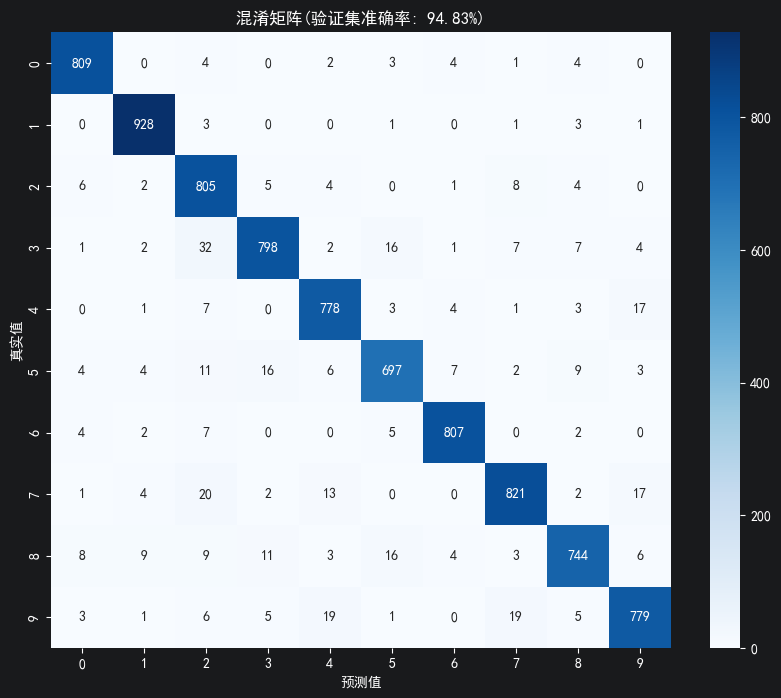

In [23]:
print("分类报告:")
print(classification_report(y_val,val_pred_best))
plt.figure(figsize=(10,8))
cm=confusion_matrix(y_val,val_pred_best)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title(f"混淆矩阵(验证集准确率: {val_acc_best:.2%})")
plt.ylabel('真实值')
plt.xlabel('预测值')
plt.savefig('confusion_matrix.png')
plt.show()

评估最佳模型——分类报告与混淆矩阵
1.输出每个数字（0~9）的精确率、召回率、F1-score。对于数字识别，我们关心哪些数字容易被混淆（如 4 和 9，7 和 1）。
2.计算混淆矩阵（10×10），行是真实值，列是预测值。对角线上的值越大越好。
3.可视化混淆矩阵，颜色越深表示该位置样本越多。可快速发现模型在哪些数字对之间容易犯错。

In [24]:
print("正在预测测试集...")
test_predictions=best_svm.predict(X_test_scaled)
print("预测完成！")
submission=pd.DataFrame({'ImageId':np.arange(1,len(test_predictions)+1),'Label':test_predictions})
submission.to_csv('submission_svm.csv',index=False)
print("提交文件已生成：submission_svm.csv")
print(submission.head())

正在预测测试集...
预测完成！
提交文件已生成：submission_svm.csv
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      4
4        5      3
